In [2]:
# %% [markdown]
# # Rest-to-Task Generalization Gap Analysis
# 
# **Purpose**: Quantify the accuracy drop from rest (CV) to task for each model.
# This IS your **core thesis measure** — the gap represents functional reorganization magnitude.
# 
# **Thesis Contribution**: Directly tests your hypothesis that classification errors 
# reveal task-induced reorganization during the Gender Stroop task.
# 
# ## Key Questions:
# 1. Which strategy shows the smallest gap? (best at capturing stable organization)
# 2. Which hemisphere reorganizes more during the Gender Stroop task?
# 3. Does full brain show different reorganization than individual hemispheres?
# 
# ## Important Note:
# For hemispheres, task testing was run only once (likely OvO model), so task 
# accuracy is shared across strategies. This analysis acknowledges this limitation.

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from typing import Dict, Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight'
})

# Color scheme
COLORS = {
    'cv': '#3498db',        # Blue for CV/Rest
    'task': '#e74c3c',      # Red for Task
    'drop': '#f39c12',      # Orange for drop
    'multinomial': '#2ecc71',
    'ovr': '#3498db',
    'ovo': '#9b59b6',
    'full': '#1abc9c',
    'left': '#e74c3c',
    'right': '#f39c12'
}

print("✓ Imports complete")

✓ Imports complete


In [4]:

OUTPUT_DIR = Path("reports/generalization_gap_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load summary from previous analysis (or recreate)
SUMMARY_PATH = Path("reports/performance_comparison/performance_summary.csv")

if SUMMARY_PATH.exists():
    summary_df = pd.read_csv(SUMMARY_PATH)
    print(f"✓ Loaded summary from: {SUMMARY_PATH}")
else:
    # If not available, create it here
    print("Summary not found. Please run 01_performance_comparison_analysis.py first.")
    print("Or provide the data manually below.")
    
    # Manual data entry based on your results
    summary_df = pd.DataFrame({
        'data_type': ['full', 'full', 'full', 'left', 'left', 'left', 'right', 'right', 'right'],
        'strategy': ['multinomial', 'ovr', 'ovo', 'multinomial', 'ovr', 'ovo', 'multinomial', 'ovr', 'ovo'],
        'n_regions': [232, 232, 232, 116, 116, 116, 116, 116, 116],
        'cv_accuracy': [0.924126, 0.931708, 0.868785, 0.918180, 0.922645, 0.881427, 0.913562, 0.920836, 0.875269],
        'task_accuracy': [0.892392, 0.896336, 0.830496, 0.835862, 0.835862, 0.835862, 0.823578, 0.823578, 0.823578],
    })
    summary_df['accuracy_drop'] = summary_df['cv_accuracy'] - summary_df['task_accuracy']
    summary_df['accuracy_drop_pct'] = (summary_df['accuracy_drop'] / summary_df['cv_accuracy']) * 100
    print("✓ Created summary from manual data")

# Display
print("\n" + "="*80)
print("LOADED DATA")
print("="*80)
print(summary_df[['data_type', 'strategy', 'cv_accuracy', 'task_accuracy', 'accuracy_drop', 'accuracy_drop_pct']].to_string(index=False))

✓ Loaded summary from: reports/performance_comparison/performance_summary.csv

LOADED DATA
data_type    strategy  cv_accuracy  task_accuracy  accuracy_drop  accuracy_drop_pct
     full multinomial     0.924126       0.892392       0.031734           3.433961
     full         ovr     0.931708       0.896336       0.035372           3.796444
     full         ovo     0.868785       0.830496       0.038289           4.407185
     left multinomial     0.918180       0.869310       0.048870           5.322491
     left         ovr     0.922645       0.875690       0.046955           5.089180
     left         ovo     0.881427       0.835862       0.045565           5.169454
    right multinomial     0.913562       0.863060       0.050502           5.528014
    right         ovr     0.920836       0.871034       0.049801           5.408284
    right         ovo     0.875269       0.823578       0.051692           5.905817


In [5]:
def calculate_gap_statistics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate comprehensive gap statistics for each model.
    """
    stats_df = df.copy()
    
    # Absolute gap (already calculated)
    stats_df['gap_absolute'] = stats_df['accuracy_drop']
    
    # Relative gap (percentage of CV accuracy)
    stats_df['gap_relative_pct'] = stats_df['accuracy_drop_pct']
    
    # Normalized by chance level
    stats_df['chance_level'] = 1 / stats_df['n_regions']
    stats_df['cv_above_chance'] = stats_df['cv_accuracy'] - stats_df['chance_level']
    stats_df['task_above_chance'] = stats_df['task_accuracy'] - stats_df['chance_level']
    
    # Retention rate: how much of "learned" organization is retained during task
    # (task_above_chance / cv_above_chance) * 100
    stats_df['retention_rate'] = (stats_df['task_above_chance'] / stats_df['cv_above_chance']) * 100
    
    # Reorganization rate = 100 - retention rate
    stats_df['reorganization_rate'] = 100 - stats_df['retention_rate']
    
    return stats_df

# Calculate statistics
gap_stats = calculate_gap_statistics(summary_df)

print("\n" + "="*80)
print("GENERALIZATION GAP STATISTICS")
print("="*80)
print("\nAbsolute and Relative Gap:")
print(gap_stats[['data_type', 'strategy', 'gap_absolute', 'gap_relative_pct']].to_string(index=False))

print("\nRetention vs Reorganization:")
print(gap_stats[['data_type', 'strategy', 'retention_rate', 'reorganization_rate']].to_string(index=False))

# Save
gap_stats.to_csv(OUTPUT_DIR / "gap_statistics.csv", index=False)
print(f"\n✓ Saved: {OUTPUT_DIR / 'gap_statistics.csv'}")


GENERALIZATION GAP STATISTICS

Absolute and Relative Gap:
data_type    strategy  gap_absolute  gap_relative_pct
     full multinomial      0.031734          3.433961
     full         ovr      0.035372          3.796444
     full         ovo      0.038289          4.407185
     left multinomial      0.048870          5.322491
     left         ovr      0.046955          5.089180
     left         ovo      0.045565          5.169454
    right multinomial      0.050502          5.528014
    right         ovr      0.049801          5.408284
    right         ovo      0.051692          5.905817

Retention vs Reorganization:
data_type    strategy  retention_rate  reorganization_rate
     full multinomial       96.549947             3.450053
     full         ovr       96.185911             3.814089
     full         ovo       95.570840             4.429160
     left multinomial       94.627063             5.372937
     left         ovr       94.862821             5.137179
     left        

✓ Saved: reports/generalization_gap_analysis/fig1_accuracy_waterfall.png


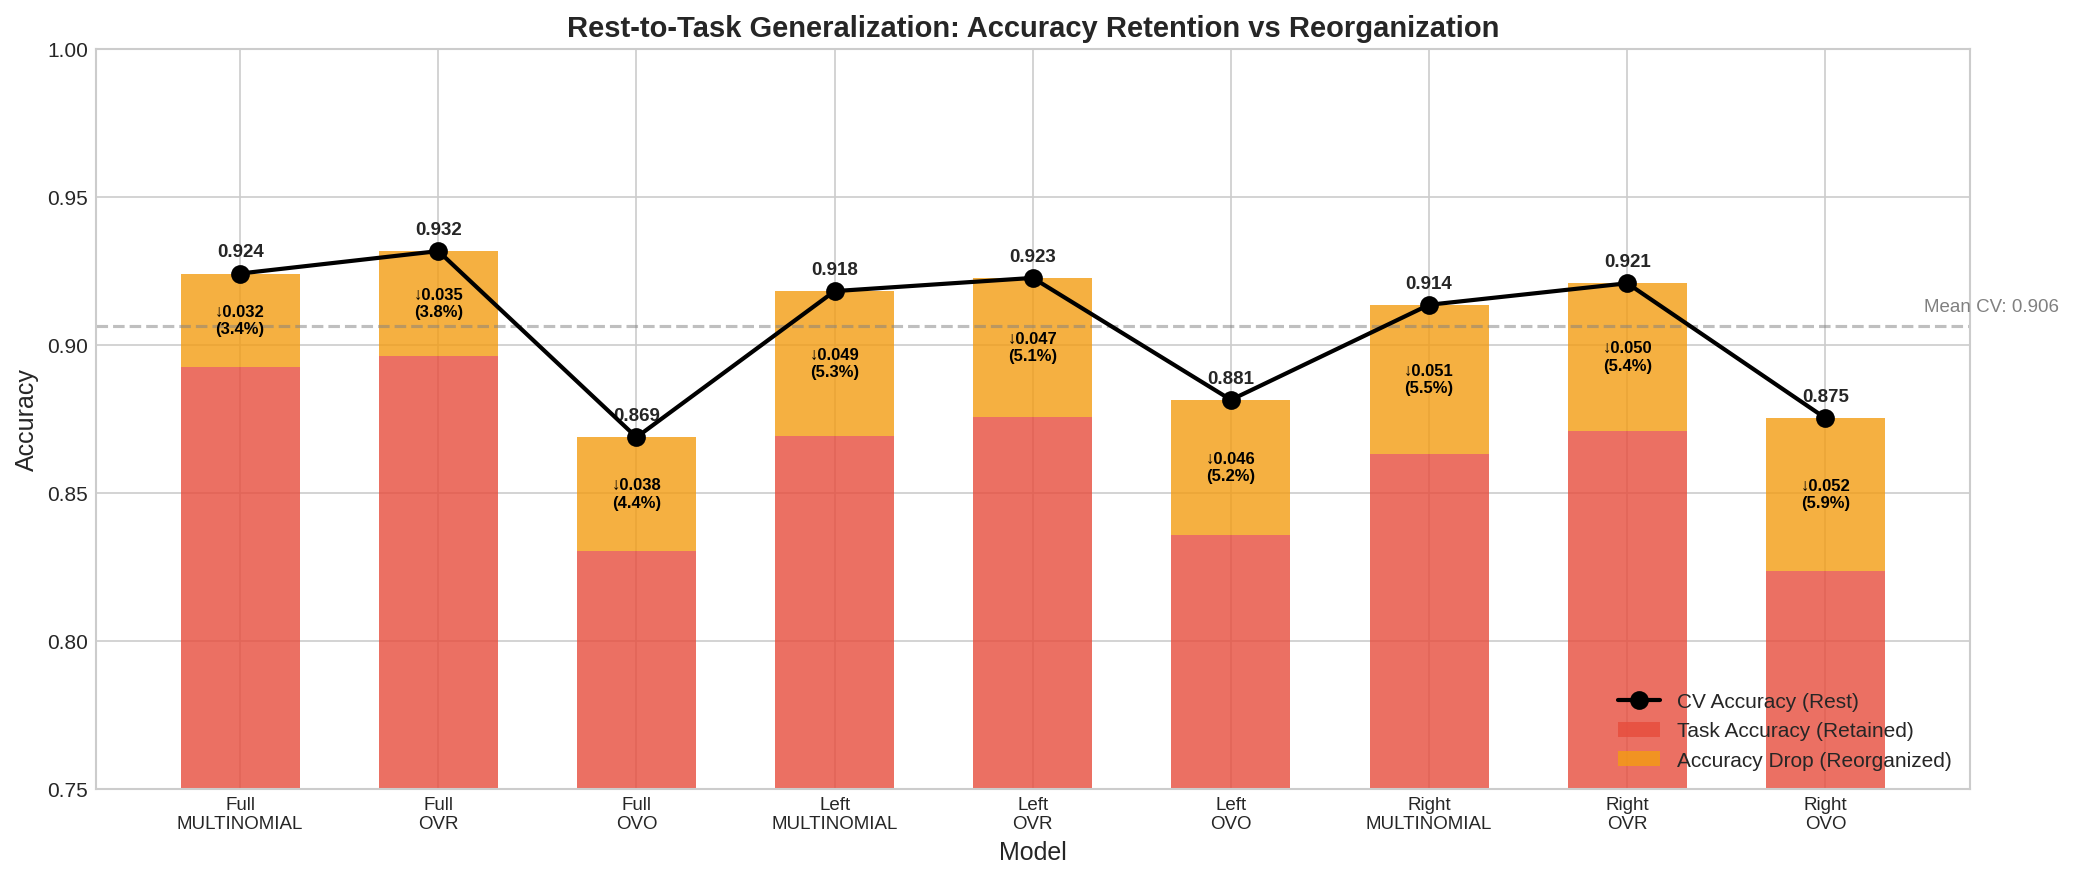

In [6]:
def plot_accuracy_waterfall(df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Create a waterfall chart showing CV → Task transition for all models.
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Prepare data
    models = [f"{row['data_type'].capitalize()}\n{row['strategy'].upper()}" 
              for _, row in df.iterrows()]
    
    x = np.arange(len(models))
    width = 0.6
    
    # Plot task accuracy as base (what remains)
    bars_task = ax.bar(x, df['task_accuracy'], width, 
                       label='Task Accuracy (Retained)', color=COLORS['task'], alpha=0.8)
    
    # Plot the gap on top (what was lost)
    bars_gap = ax.bar(x, df['accuracy_drop'], width, bottom=df['task_accuracy'],
                      label='Accuracy Drop (Reorganized)', color=COLORS['drop'], alpha=0.8)
    
    # Add CV accuracy line
    ax.plot(x, df['cv_accuracy'], 'ko-', markersize=8, linewidth=2, 
            label='CV Accuracy (Rest)', zorder=5)
    
    # Add value labels
    for i, (_, row) in enumerate(df.iterrows()):
        # CV accuracy label
        ax.annotate(f"{row['cv_accuracy']:.3f}", 
                   xy=(i, row['cv_accuracy']), xytext=(0, 8),
                   textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
        
        # Gap label (in the middle of the gap bar)
        gap_center = row['task_accuracy'] + row['accuracy_drop']/2
        ax.annotate(f"↓{row['accuracy_drop']:.3f}\n({row['accuracy_drop_pct']:.1f}%)", 
                   xy=(i, gap_center), ha='center', va='center', fontsize=8,
                   color='black', fontweight='bold')
    
    # Formatting
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_title('Rest-to-Task Generalization: Accuracy Retention vs Reorganization', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=9)
    ax.set_ylim(0.75, 1.0)
    ax.legend(loc='lower right')
    
    # Add horizontal line at mean CV
    ax.axhline(y=df['cv_accuracy'].mean(), color='gray', linestyle='--', alpha=0.5)
    ax.text(len(x)-0.5, df['cv_accuracy'].mean() + 0.005, 
            f"Mean CV: {df['cv_accuracy'].mean():.3f}", fontsize=9, color='gray')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create waterfall plot
plot_accuracy_waterfall(summary_df, OUTPUT_DIR / "fig1_accuracy_waterfall.png")

QUESTION 1: Which strategy shows the smallest gap?

Strategy-wise Statistics:
   strategy  cv_accuracy_mean  cv_accuracy_std  task_accuracy_mean  task_accuracy_std  accuracy_drop_mean  accuracy_drop_std  accuracy_drop_pct_mean  accuracy_drop_pct_std
multinomial            0.9186           0.0053              0.8749             0.0154              0.0437             0.0104                  4.7615                 1.1543
        ovo            0.8752           0.0063              0.8300             0.0062              0.0452             0.0067                  5.1608                 0.7494
        ovr            0.9251           0.0058              0.8810             0.0135              0.0440             0.0076                  4.7646                 0.8535

✓ FINDING: MULTINOMIAL shows smallest mean gap (0.0437)
  → Better at capturing stable brain organization that persists during task
✓ Saved: reports/generalization_gap_analysis/fig2_strategy_gap_comparison.png


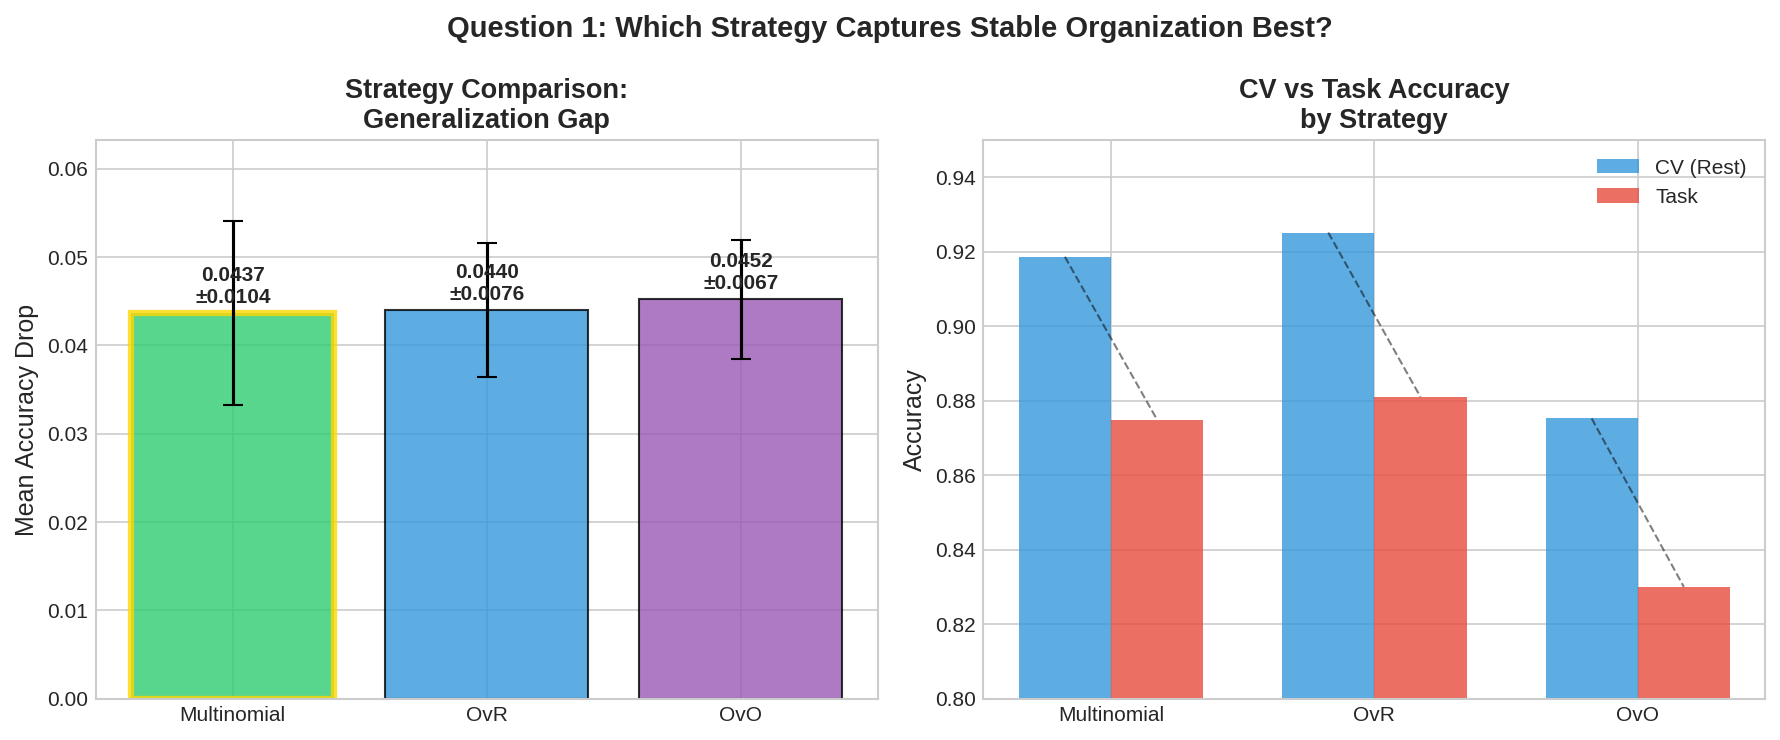

In [ ]:
def analyze_strategy_gaps(df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Analyze which classification strategy shows the smallest generalization gap.
    """
    print("="*80)
    print("QUESTION 1: Which strategy shows the smallest gap?")
    print("="*80)
    
    # Group by strategy
    strategy_stats = df.groupby('strategy').agg({
        'cv_accuracy': ['mean', 'std'],
        'task_accuracy': ['mean', 'std'],
        'accuracy_drop': ['mean', 'std'],
        'accuracy_drop_pct': ['mean', 'std']
    }).round(4)
    
    # Flatten column names
    strategy_stats.columns = ['_'.join(col) for col in strategy_stats.columns]
    strategy_stats = strategy_stats.reset_index()
    
    print("\nStrategy-wise Statistics:")
    print(strategy_stats.to_string(index=False))
    
    # Find best strategy (smallest gap)
    best_idx = strategy_stats['accuracy_drop_mean'].idxmin()
    best_strategy = strategy_stats.loc[best_idx, 'strategy']
    best_gap = strategy_stats.loc[best_idx, 'accuracy_drop_mean']
    
    print(f"\n✓ FINDING: {best_strategy.upper()} shows smallest mean gap ({best_gap:.4f})")
    print(f"  → Better at capturing stable brain organization that persists during task")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Gap comparison
    ax1 = axes[0]
    strategies = ['multinomial', 'ovr', 'ovo']
    strategy_labels = ['Multinomial', 'OvR', 'OvO']
    colors_strat = [COLORS['multinomial'], COLORS['ovr'], COLORS['ovo']]
    
    means = [strategy_stats[strategy_stats['strategy']==s]['accuracy_drop_mean'].values[0] for s in strategies]
    stds = [strategy_stats[strategy_stats['strategy']==s]['accuracy_drop_std'].values[0] for s in strategies]
    
    bars = ax1.bar(strategy_labels, means, yerr=stds, capsize=5, 
                   color=colors_strat, alpha=0.8, edgecolor='black')
    
    # Add value labels
    for bar, mean, std in zip(bars, means, stds):
        ax1.annotate(f'{mean:.4f}\n±{std:.4f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
    
    ax1.set_ylabel('Mean Accuracy Drop')
    ax1.set_title('Strategy Comparison:\nGeneralization Gap', fontweight='bold')
    ax1.set_ylim(0, max(means) * 1.4)
    
    # Highlight best
    best_bar_idx = strategies.index(best_strategy)
    bars[best_bar_idx].set_edgecolor('gold')
    bars[best_bar_idx].set_linewidth(3)
    
    # Plot 2: CV vs Task by strategy
    ax2 = axes[1]
    x = np.arange(3)
    width = 0.35
    
    cv_means = [strategy_stats[strategy_stats['strategy']==s]['cv_accuracy_mean'].values[0] for s in strategies]
    task_means = [strategy_stats[strategy_stats['strategy']==s]['task_accuracy_mean'].values[0] for s in strategies]
    
    ax2.bar(x - width/2, cv_means, width, label='CV (Rest)', color=COLORS['cv'], alpha=0.8)
    ax2.bar(x + width/2, task_means, width, label='Task', color=COLORS['task'], alpha=0.8)
    
    # Connect with lines to show drop
    for i in range(3):
        ax2.plot([i-width/2, i+width/2], [cv_means[i], task_means[i]], 
                'k--', alpha=0.5, linewidth=1)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(strategy_labels)
    ax2.set_ylabel('Accuracy')
    ax2.set_title('CV vs Task Accuracy\nby Strategy', fontweight='bold')
    ax2.legend()
    ax2.set_ylim(0.8, 0.95)
    
    plt.suptitle('Question 1: Which Strategy Captures Stable Organization Best?', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"✓ Saved: {save_path}")
    
    plt.show()
    
    return strategy_stats

# Analyze strategies
strategy_comparison = analyze_strategy_gaps(summary_df, OUTPUT_DIR / "fig2_strategy_gap_comparison.png")


QUESTION 2: Which hemisphere reorganizes more during Gender Stroop?

⚠ Note: Using OvO models for hemisphere comparison
  (Task testing was run with OvO model for both hemispheres)

OvO Model Comparison (Fair Comparison):
data_type  cv_accuracy  task_accuracy  accuracy_drop  accuracy_drop_pct
     left     0.881427       0.835862       0.045565           5.169454
    right     0.875269       0.823578       0.051692           5.905817

✓ FINDING: RIGHT hemisphere shows MORE reorganization
  Left hemisphere drop:  0.0456 (5.17%)
  Right hemisphere drop: 0.0517 (5.91%)
  Difference: 0.0061

📊 INTERPRETATION (Gender Stroop Task):
  The Gender Stroop involves:
    • Reading gender words (language - typically LEFT hemisphere)
    • Viewing faces (face processing - typically RIGHT hemisphere)
    • Conflict resolution (prefrontal regions - bilateral)
    • Motor response (button press - contralateral motor cortex)

  → Right hemisphere showing more reorganization (0.0517 vs 0.0456)
    may r

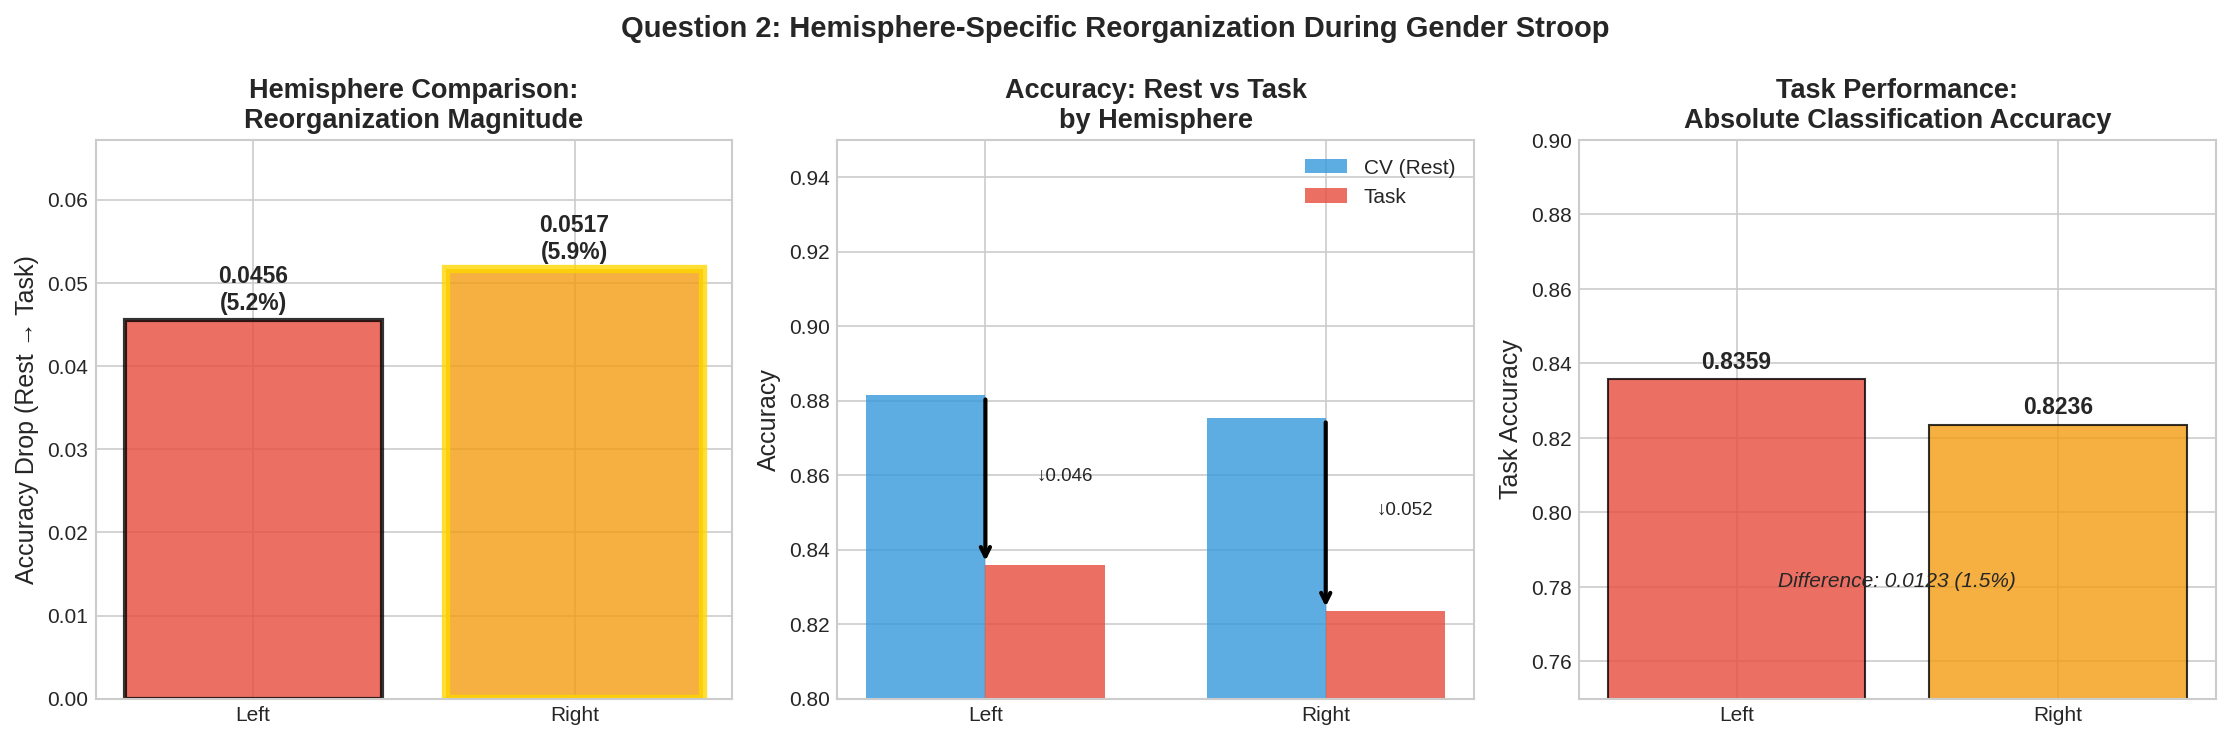

In [ ]:
def analyze_hemisphere_gaps(df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Analyze which hemisphere shows more reorganization during the Gender Stroop task.
    """
    print("\n" + "="*80)
    print("QUESTION 2: Which hemisphere reorganizes more during Gender Stroop?")
    print("="*80)
    
    # Filter to hemispheres only
    hemi_df = df[df['data_type'].isin(['left', 'right'])].copy()
    
    # Since task accuracy is the same within each hemisphere, 
    # use OvO results for fair comparison (matching task model)
    ovo_comparison = hemi_df[hemi_df['strategy'] == 'ovo'].copy()
    
    print("\n⚠ Note: Using OvO models for hemisphere comparison")
    print("  (Task testing was run with OvO model for both hemispheres)")
    
    print("\nOvO Model Comparison (Fair Comparison):")
    print(ovo_comparison[['data_type', 'cv_accuracy', 'task_accuracy', 'accuracy_drop', 'accuracy_drop_pct']].to_string(index=False))
    
    # Extract values
    left_row = ovo_comparison[ovo_comparison['data_type'] == 'left'].iloc[0]
    right_row = ovo_comparison[ovo_comparison['data_type'] == 'right'].iloc[0]
    
    left_drop = left_row['accuracy_drop']
    right_drop = right_row['accuracy_drop']
    left_task = left_row['task_accuracy']
    right_task = right_row['task_accuracy']
    
    # Determine which reorganizes more
    if right_drop > left_drop:
        more_reorg = "RIGHT"
        diff = right_drop - left_drop
    else:
        more_reorg = "LEFT"
        diff = left_drop - right_drop
    
    print(f"\n✓ FINDING: {more_reorg} hemisphere shows MORE reorganization")
    print(f"  Left hemisphere drop:  {left_drop:.4f} ({left_row['accuracy_drop_pct']:.2f}%)")
    print(f"  Right hemisphere drop: {right_drop:.4f} ({right_row['accuracy_drop_pct']:.2f}%)")
    print(f"  Difference: {diff:.4f}")
    
    # Interpretation for Gender Stroop
    print("\n📊 INTERPRETATION (Gender Stroop Task):")
    print("  The Gender Stroop involves:")
    print("    • Reading gender words (language - typically LEFT hemisphere)")
    print("    • Viewing faces (face processing - typically RIGHT hemisphere)")
    print("    • Conflict resolution (prefrontal regions - bilateral)")
    print("    • Motor response (button press - contralateral motor cortex)")
    
    if more_reorg == "RIGHT":
        print(f"\n  → Right hemisphere showing more reorganization ({right_drop:.4f} vs {left_drop:.4f})")
        print("    may reflect face processing demands or visuospatial attention")
    else:
        print(f"\n  → Left hemisphere showing more reorganization ({left_drop:.4f} vs {right_drop:.4f})")
        print("    may reflect language/reading demands of word processing")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: Direct comparison bar chart
    ax1 = axes[0]
    hemispheres = ['Left', 'Right']
    drops = [left_drop, right_drop]
    colors_hemi = [COLORS['left'], COLORS['right']]
    
    bars = ax1.bar(hemispheres, drops, color=colors_hemi, alpha=0.8, edgecolor='black', linewidth=2)
    
    for bar, drop, pct in zip(bars, drops, [left_row['accuracy_drop_pct'], right_row['accuracy_drop_pct']]):
        ax1.annotate(f'{drop:.4f}\n({pct:.1f}%)', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=11, fontweight='bold')
    
    ax1.set_ylabel('Accuracy Drop (Rest → Task)')
    ax1.set_title('Hemisphere Comparison:\nReorganization Magnitude', fontweight='bold')
    ax1.set_ylim(0, max(drops) * 1.3)
    
    # Highlight the one with more reorganization
    winner_idx = 1 if more_reorg == "RIGHT" else 0
    bars[winner_idx].set_edgecolor('gold')
    bars[winner_idx].set_linewidth(4)
    
    # Plot 2: CV vs Task for each hemisphere
    ax2 = axes[1]
    x = np.arange(2)
    width = 0.35
    
    cv_vals = [left_row['cv_accuracy'], right_row['cv_accuracy']]
    task_vals = [left_task, right_task]
    
    ax2.bar(x - width/2, cv_vals, width, label='CV (Rest)', color=COLORS['cv'], alpha=0.8)
    ax2.bar(x + width/2, task_vals, width, label='Task', color=COLORS['task'], alpha=0.8)
    
    # Add drop arrows
    for i, (cv, task) in enumerate(zip(cv_vals, task_vals)):
        ax2.annotate('', xy=(i, task), xytext=(i, cv),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))
        ax2.text(i + 0.15, (cv + task)/2, f'↓{cv-task:.3f}', fontsize=9)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(hemispheres)
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy: Rest vs Task\nby Hemisphere', fontweight='bold')
    ax2.legend()
    ax2.set_ylim(0.8, 0.95)
    
    # Plot 3: Task accuracy comparison (absolute performance)
    ax3 = axes[2]
    task_accs = [left_task, right_task]
    bars3 = ax3.bar(hemispheres, task_accs, color=colors_hemi, alpha=0.8, edgecolor='black')
    
    for bar, acc in zip(bars3, task_accs):
        ax3.annotate(f'{acc:.4f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=11, fontweight='bold')
    
    ax3.set_ylabel('Task Accuracy')
    ax3.set_title('Task Performance:\nAbsolute Classification Accuracy', fontweight='bold')
    ax3.set_ylim(0.75, 0.9)
    
    # Add interpretation text
    diff_pct = abs(left_task - right_task) / ((left_task + right_task)/2) * 100
    ax3.text(0.5, 0.78, f'Difference: {abs(left_task - right_task):.4f} ({diff_pct:.1f}%)', 
            ha='center', fontsize=10, style='italic')
    
    plt.suptitle('Question 2: Hemisphere-Specific Reorganization During Gender Stroop', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"\n✓ Saved: {save_path}")
    
    plt.show()
    
    return {
        'left_drop': left_drop,
        'right_drop': right_drop,
        'more_reorganization': more_reorg,
        'difference': diff
    }

# Analyze hemispheres
hemisphere_results = analyze_hemisphere_gaps(summary_df, OUTPUT_DIR / "fig3_hemisphere_comparison.png")


QUESTION 3: Full Brain vs Hemispheres

OvO Model Comparison:
data_type  n_regions  cv_accuracy  task_accuracy  accuracy_drop  accuracy_drop_pct
     full        232     0.868785       0.830496       0.038289           4.407185
     left        116     0.881427       0.835862       0.045565           5.169454
    right        116     0.875269       0.823578       0.051692           5.905817

📊 ANALYSIS:
  Full Brain (232 regions):
    CV Accuracy:   0.8688
    Task Accuracy: 0.8305
    Drop:          0.0383 (4.41%)

  Left Hemisphere (116 regions):
    CV Accuracy:   0.8814
    Task Accuracy: 0.8359
    Drop:          0.0456 (5.17%)

  Right Hemisphere (116 regions):
    CV Accuracy:   0.8753
    Task Accuracy: 0.8236
    Drop:          0.0517 (5.91%)

✓ KEY FINDINGS:
  1. Full brain drop (0.0383) vs Average hemisphere drop (0.0486)
     → Full brain shows LESS reorganization than average of hemispheres
     → Cross-hemisphere connections may provide stabilizing information

  2. Task 

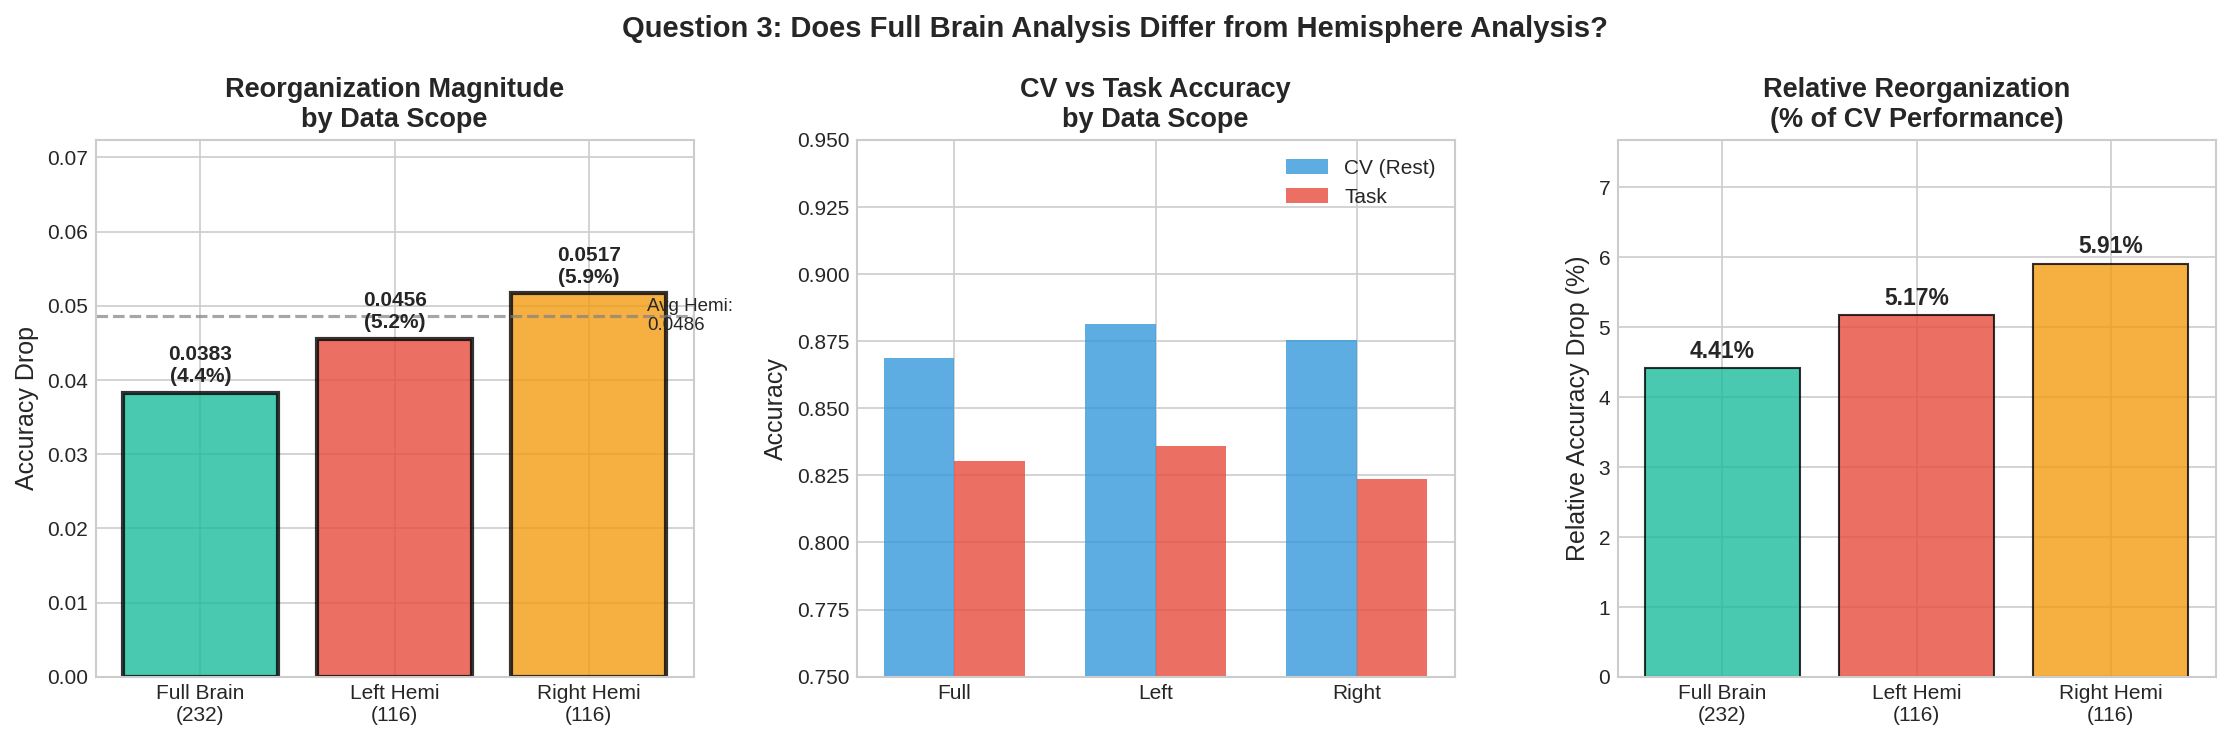

In [9]:

def analyze_fullbrain_vs_hemispheres(df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Compare full brain vs hemisphere-specific reorganization patterns.
    """
    print("\n" + "="*80)
    print("QUESTION 3: Full Brain vs Hemispheres")
    print("="*80)
    
    # Use OvO for fair comparison (since hemisphere task testing used OvO)
    ovo_df = df[df['strategy'] == 'ovo'].copy()
    
    print("\nOvO Model Comparison:")
    print(ovo_df[['data_type', 'n_regions', 'cv_accuracy', 'task_accuracy', 'accuracy_drop', 'accuracy_drop_pct']].to_string(index=False))
    
    full_row = ovo_df[ovo_df['data_type'] == 'full'].iloc[0]
    left_row = ovo_df[ovo_df['data_type'] == 'left'].iloc[0]
    right_row = ovo_df[ovo_df['data_type'] == 'right'].iloc[0]
    
    # Calculate expected hemisphere combination
    # If hemispheres were independent, combined accuracy would be approximately:
    # (left_acc + right_acc) / 2 (simplified assumption)
    expected_combined = (left_row['task_accuracy'] + right_row['task_accuracy']) / 2
    actual_full = full_row['task_accuracy']
    
    print(f"\n📊 ANALYSIS:")
    print(f"  Full Brain (232 regions):")
    print(f"    CV Accuracy:   {full_row['cv_accuracy']:.4f}")
    print(f"    Task Accuracy: {full_row['task_accuracy']:.4f}")
    print(f"    Drop:          {full_row['accuracy_drop']:.4f} ({full_row['accuracy_drop_pct']:.2f}%)")
    
    print(f"\n  Left Hemisphere (116 regions):")
    print(f"    CV Accuracy:   {left_row['cv_accuracy']:.4f}")
    print(f"    Task Accuracy: {left_row['task_accuracy']:.4f}")
    print(f"    Drop:          {left_row['accuracy_drop']:.4f} ({left_row['accuracy_drop_pct']:.2f}%)")
    
    print(f"\n  Right Hemisphere (116 regions):")
    print(f"    CV Accuracy:   {right_row['cv_accuracy']:.4f}")
    print(f"    Task Accuracy: {right_row['task_accuracy']:.4f}")
    print(f"    Drop:          {right_row['accuracy_drop']:.4f} ({right_row['accuracy_drop_pct']:.2f}%)")
    
    # Key findings
    avg_hemi_drop = (left_row['accuracy_drop'] + right_row['accuracy_drop']) / 2
    
    print(f"\n✓ KEY FINDINGS:")
    print(f"  1. Full brain drop ({full_row['accuracy_drop']:.4f}) vs Average hemisphere drop ({avg_hemi_drop:.4f})")
    
    if full_row['accuracy_drop'] < avg_hemi_drop:
        print(f"     → Full brain shows LESS reorganization than average of hemispheres")
        print(f"     → Cross-hemisphere connections may provide stabilizing information")
    else:
        print(f"     → Full brain shows MORE reorganization than average of hemispheres")
        print(f"     → Additional complexity from 232 regions increases vulnerability")
    
    print(f"\n  2. Task accuracy comparison:")
    print(f"     Full brain:  {full_row['task_accuracy']:.4f}")
    print(f"     Left hemi:   {left_row['task_accuracy']:.4f}")
    print(f"     Right hemi:  {right_row['task_accuracy']:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: Accuracy drop comparison
    ax1 = axes[0]
    data_types = ['Full Brain\n(232)', 'Left Hemi\n(116)', 'Right Hemi\n(116)']
    drops = [full_row['accuracy_drop'], left_row['accuracy_drop'], right_row['accuracy_drop']]
    colors_dt = [COLORS['full'], COLORS['left'], COLORS['right']]
    
    bars = ax1.bar(data_types, drops, color=colors_dt, alpha=0.8, edgecolor='black', linewidth=2)
    
    # Add value labels
    for bar, drop, row in zip(bars, drops, [full_row, left_row, right_row]):
        ax1.annotate(f'{drop:.4f}\n({row["accuracy_drop_pct"]:.1f}%)', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
    
    ax1.axhline(y=avg_hemi_drop, color='gray', linestyle='--', alpha=0.7)
    ax1.text(2.3, avg_hemi_drop, f'Avg Hemi:\n{avg_hemi_drop:.4f}', fontsize=9, va='center')
    
    ax1.set_ylabel('Accuracy Drop')
    ax1.set_title('Reorganization Magnitude\nby Data Scope', fontweight='bold')
    ax1.set_ylim(0, max(drops) * 1.4)
    
    # Plot 2: CV vs Task grouped bar
    ax2 = axes[1]
    x = np.arange(3)
    width = 0.35
    
    cv_vals = [full_row['cv_accuracy'], left_row['cv_accuracy'], right_row['cv_accuracy']]
    task_vals = [full_row['task_accuracy'], left_row['task_accuracy'], right_row['task_accuracy']]
    
    ax2.bar(x - width/2, cv_vals, width, label='CV (Rest)', color=COLORS['cv'], alpha=0.8)
    ax2.bar(x + width/2, task_vals, width, label='Task', color=COLORS['task'], alpha=0.8)
    
    ax2.set_xticks(x)
    ax2.set_xticklabels(['Full', 'Left', 'Right'])
    ax2.set_ylabel('Accuracy')
    ax2.set_title('CV vs Task Accuracy\nby Data Scope', fontweight='bold')
    ax2.legend()
    ax2.set_ylim(0.75, 0.95)
    
    # Plot 3: Relative drop (percentage)
    ax3 = axes[2]
    drop_pcts = [full_row['accuracy_drop_pct'], left_row['accuracy_drop_pct'], right_row['accuracy_drop_pct']]
    
    bars3 = ax3.bar(data_types, drop_pcts, color=colors_dt, alpha=0.8, edgecolor='black')
    
    for bar, pct in zip(bars3, drop_pcts):
        ax3.annotate(f'{pct:.2f}%', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=11, fontweight='bold')
    
    ax3.set_ylabel('Relative Accuracy Drop (%)')
    ax3.set_title('Relative Reorganization\n(% of CV Performance)', fontweight='bold')
    ax3.set_ylim(0, max(drop_pcts) * 1.3)
    
    plt.suptitle('Question 3: Does Full Brain Analysis Differ from Hemisphere Analysis?', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
        print(f"\n✓ Saved: {save_path}")
    
    plt.show()
    
    return {
        'full_drop': full_row['accuracy_drop'],
        'left_drop': left_row['accuracy_drop'],
        'right_drop': right_row['accuracy_drop'],
        'avg_hemi_drop': avg_hemi_drop
    }

# Analyze full brain vs hemispheres
fullbrain_results = analyze_fullbrain_vs_hemispheres(summary_df, OUTPUT_DIR / "fig4_fullbrain_vs_hemispheres.png")

✓ Saved: reports/generalization_gap_analysis/fig5_thesis_core_figure.png


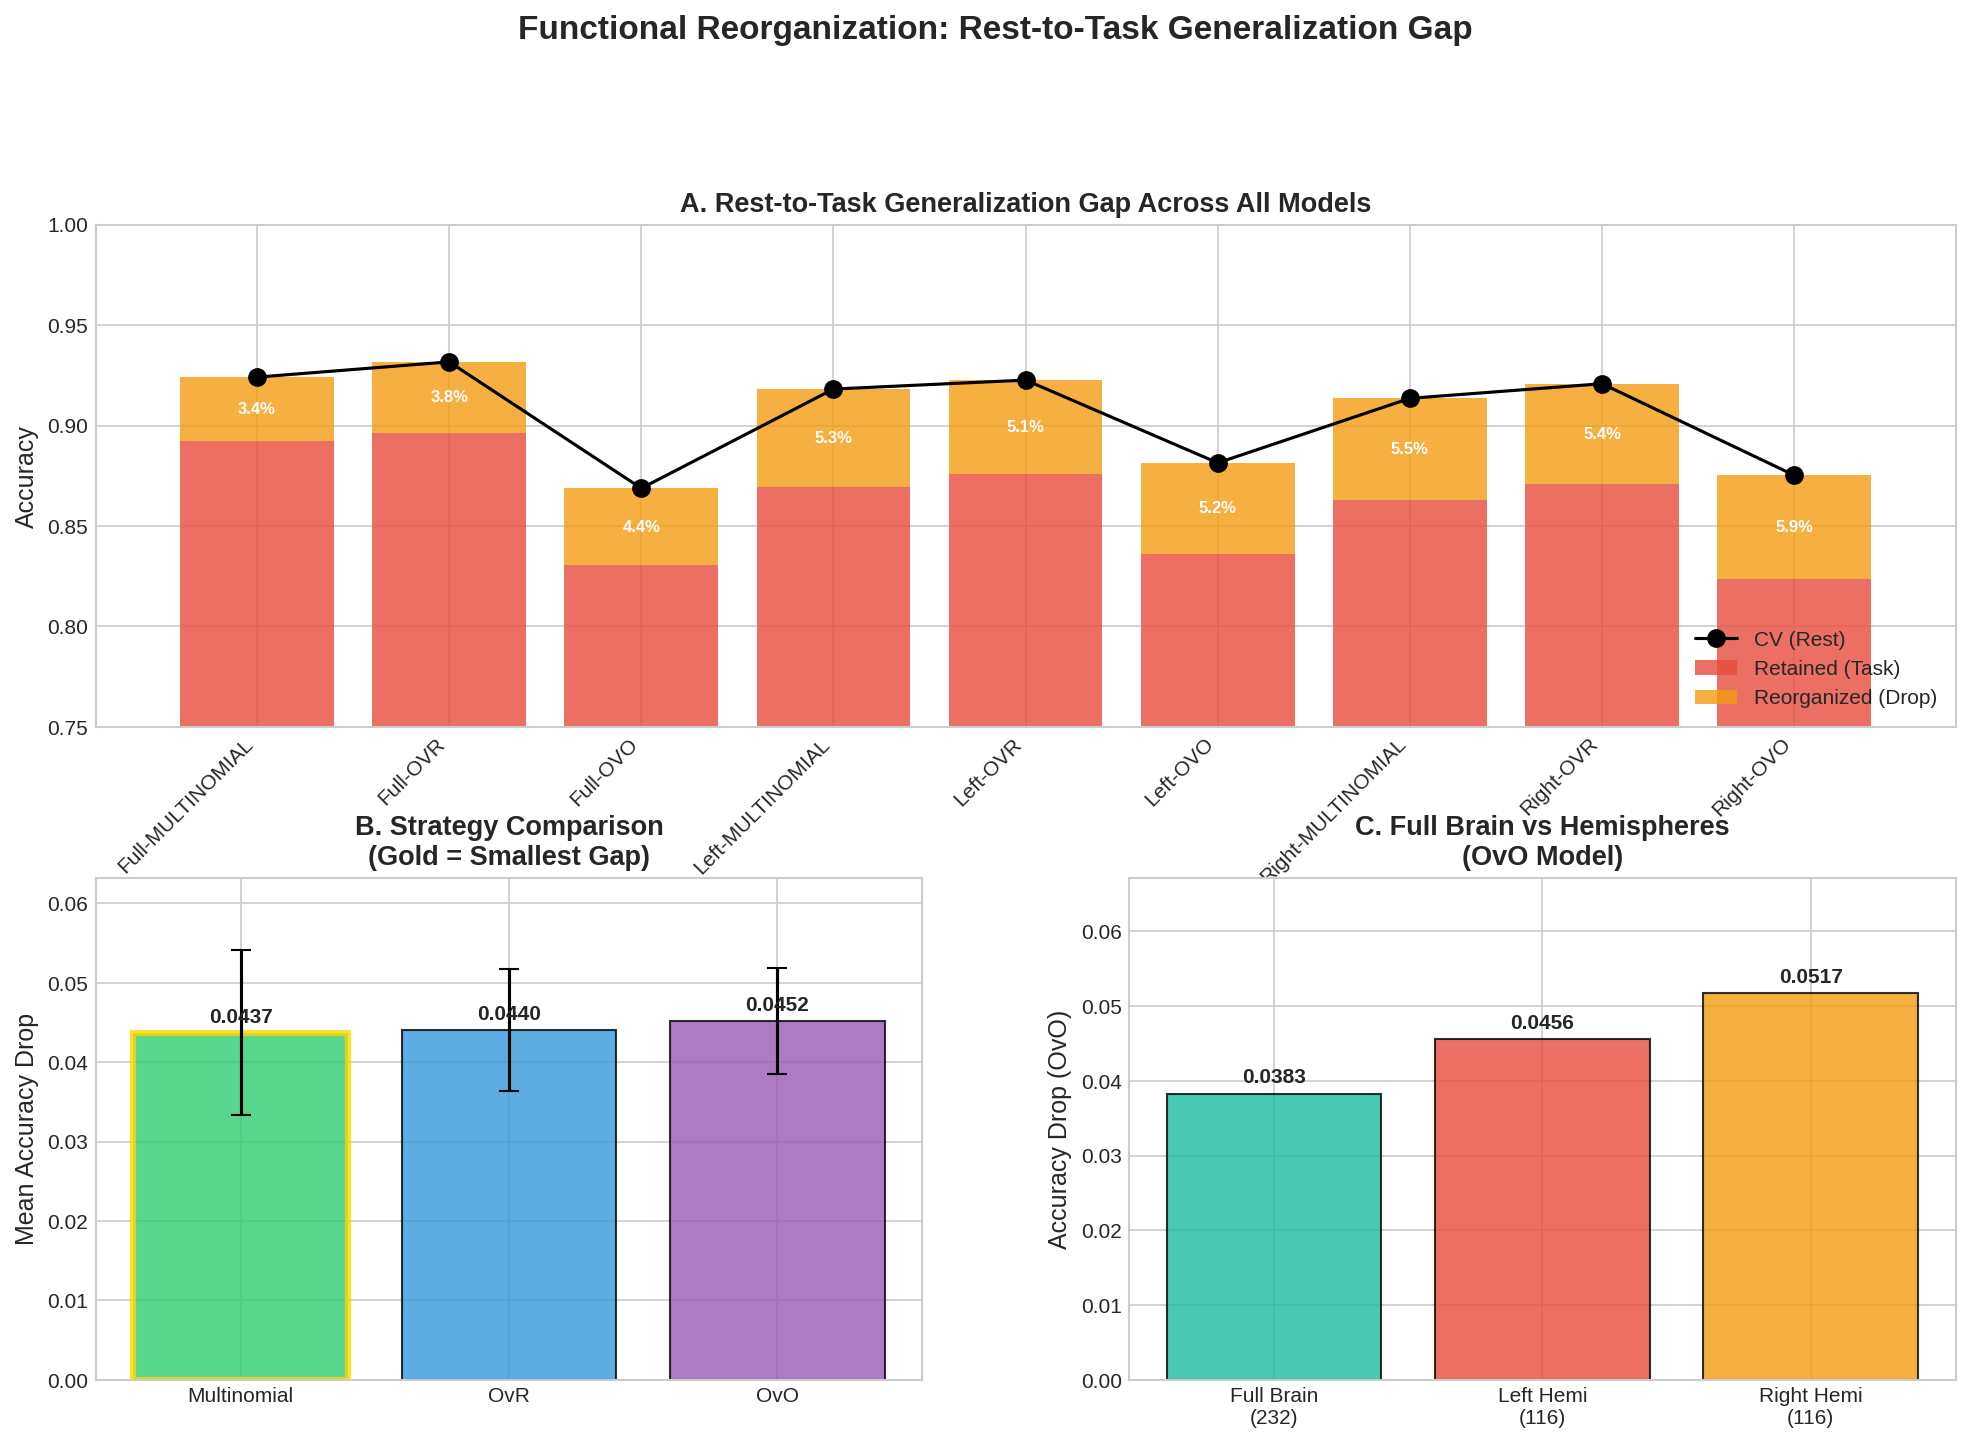

In [10]:
def create_thesis_core_figure(df: pd.DataFrame, save_path: Optional[Path] = None):
    """
    Create the core thesis figure showing rest-to-task generalization gap.
    """
    fig = plt.figure(figsize=(16, 10))
    
    # Create 2x2 grid
    gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)
    
    # --- Panel A: Overview of all models ---
    ax1 = fig.add_subplot(gs[0, :])  # Full width
    
    models = [f"{row['data_type'].capitalize()}-{row['strategy'].upper()}" 
              for _, row in df.iterrows()]
    x = np.arange(len(models))
    
    # Create stacked bar
    ax1.bar(x, df['task_accuracy'], label='Retained (Task)', color=COLORS['task'], alpha=0.8)
    ax1.bar(x, df['accuracy_drop'], bottom=df['task_accuracy'], 
            label='Reorganized (Drop)', color=COLORS['drop'], alpha=0.8)
    
    # Add CV line
    ax1.plot(x, df['cv_accuracy'], 'ko-', markersize=8, label='CV (Rest)', zorder=5)
    
    ax1.set_xticks(x)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('A. Rest-to-Task Generalization Gap Across All Models', fontweight='bold', fontsize=13)
    ax1.legend(loc='lower right')
    ax1.set_ylim(0.75, 1.0)
    
    # Add annotations for key values
    for i, (_, row) in enumerate(df.iterrows()):
        ax1.annotate(f'{row["accuracy_drop_pct"]:.1f}%', 
                    xy=(i, row['task_accuracy'] + row['accuracy_drop']/2),
                    ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    
    # --- Panel B: Strategy comparison ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    strategy_means = df.groupby('strategy')['accuracy_drop'].mean()
    strategy_stds = df.groupby('strategy')['accuracy_drop'].std()
    
    strategies = ['multinomial', 'ovr', 'ovo']
    means = [strategy_means[s] for s in strategies]
    stds = [strategy_stds[s] for s in strategies]
    colors_s = [COLORS['multinomial'], COLORS['ovr'], COLORS['ovo']]
    
    bars = ax2.bar(['Multinomial', 'OvR', 'OvO'], means, yerr=stds, capsize=5,
                   color=colors_s, alpha=0.8, edgecolor='black')
    
    # Find and highlight best (smallest gap)
    best_idx = np.argmin(means)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    for bar, mean in zip(bars, means):
        ax2.annotate(f'{mean:.4f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
    
    ax2.set_ylabel('Mean Accuracy Drop')
    ax2.set_title('B. Strategy Comparison\n(Gold = Smallest Gap)', fontweight='bold')
    ax2.set_ylim(0, max(means) * 1.4)
    
    # --- Panel C: Data type comparison ---
    ax3 = fig.add_subplot(gs[1, 1])
    
    # Use OvO for fair comparison
    ovo_df = df[df['strategy'] == 'ovo']
    data_types = ['full', 'left', 'right']
    drops = [ovo_df[ovo_df['data_type']==dt]['accuracy_drop'].values[0] for dt in data_types]
    colors_d = [COLORS['full'], COLORS['left'], COLORS['right']]
    
    bars = ax3.bar(['Full Brain\n(232)', 'Left Hemi\n(116)', 'Right Hemi\n(116)'], 
                   drops, color=colors_d, alpha=0.8, edgecolor='black')
    
    for bar, drop in zip(bars, drops):
        ax3.annotate(f'{drop:.4f}', 
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', fontsize=10, fontweight='bold')
    
    ax3.set_ylabel('Accuracy Drop (OvO)')
    ax3.set_title('C. Full Brain vs Hemispheres\n(OvO Model)', fontweight='bold')
    ax3.set_ylim(0, max(drops) * 1.3)
    
    plt.suptitle('Functional Reorganization: Rest-to-Task Generalization Gap', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Saved: {save_path}")
    
    plt.show()

# Create core thesis figure
create_thesis_core_figure(summary_df, OUTPUT_DIR / "fig5_thesis_core_figure.png")

In [11]:
def compute_effect_sizes(df: pd.DataFrame):
    """
    Compute effect sizes for key comparisons.
    """
    print("\n" + "="*80)
    print("EFFECT SIZE ANALYSIS")
    print("="*80)
    
    # 1. Strategy comparison using OvO as reference
    strategies = ['multinomial', 'ovr', 'ovo']
    drops = {s: df[df['strategy']==s]['accuracy_drop'].values for s in strategies}
    
    print("\n1. STRATEGY DIFFERENCES (vs OvO):")
    ovo_mean = drops['ovo'].mean()
    for s in ['multinomial', 'ovr']:
        diff = drops[s].mean() - ovo_mean
        print(f"   {s.upper()} - OvO = {diff:+.4f}")
    
    # 2. Hemisphere comparison (using OvO)
    ovo_df = df[df['strategy'] == 'ovo']
    left_drop = ovo_df[ovo_df['data_type']=='left']['accuracy_drop'].values[0]
    right_drop = ovo_df[ovo_df['data_type']=='right']['accuracy_drop'].values[0]
    full_drop = ovo_df[ovo_df['data_type']=='full']['accuracy_drop'].values[0]
    
    print("\n2. HEMISPHERE DIFFERENCES (OvO model):")
    print(f"   Right - Left = {right_drop - left_drop:+.4f}")
    print(f"   Full - Left  = {full_drop - left_drop:+.4f}")
    print(f"   Full - Right = {full_drop - right_drop:+.4f}")
    
    # 3. Relative magnitude
    print("\n3. RELATIVE REORGANIZATION:")
    for _, row in df.iterrows():
        print(f"   {row['data_type']:6} {row['strategy']:12}: {row['accuracy_drop_pct']:.2f}% of CV performance")
    
    # 4. Improvement over chance
    print("\n4. TASK ACCURACY VS CHANCE:")
    for _, row in df.iterrows():
        chance = 1 / row['n_regions']
        improvement = row['task_accuracy'] / chance
        print(f"   {row['data_type']:6} {row['strategy']:12}: {improvement:.1f}x chance level")

# Compute effect sizes
compute_effect_sizes(summary_df)


EFFECT SIZE ANALYSIS

1. STRATEGY DIFFERENCES (vs OvO):
   MULTINOMIAL - OvO = -0.0015
   OVR - OvO = -0.0011

2. HEMISPHERE DIFFERENCES (OvO model):
   Right - Left = +0.0061
   Full - Left  = -0.0073
   Full - Right = -0.0134

3. RELATIVE REORGANIZATION:
   full   multinomial : 3.43% of CV performance
   full   ovr         : 3.80% of CV performance
   full   ovo         : 4.41% of CV performance
   left   multinomial : 5.32% of CV performance
   left   ovr         : 5.09% of CV performance
   left   ovo         : 5.17% of CV performance
   right  multinomial : 5.53% of CV performance
   right  ovr         : 5.41% of CV performance
   right  ovo         : 5.91% of CV performance

4. TASK ACCURACY VS CHANCE:
   full   multinomial : 207.0x chance level
   full   ovr         : 207.9x chance level
   full   ovo         : 192.7x chance level
   left   multinomial : 100.8x chance level
   left   ovr         : 101.6x chance level
   left   ovo         : 97.0x chance level
   right  multinom

In [12]:

def generate_gap_analysis_summary(df: pd.DataFrame) -> str:
    """
    Generate thesis-ready summary of generalization gap analysis.
    """
    lines = []
    lines.append("="*80)
    lines.append("REST-TO-TASK GENERALIZATION GAP: KEY FINDINGS")
    lines.append("="*80)
    
    # Overall statistics
    mean_drop = df['accuracy_drop'].mean()
    mean_drop_pct = df['accuracy_drop_pct'].mean()
    
    lines.append(f"\n## OVERALL")
    lines.append(f"Mean generalization gap: {mean_drop:.4f} ({mean_drop_pct:.2f}%)")
    lines.append(f"Range: {df['accuracy_drop'].min():.4f} - {df['accuracy_drop'].max():.4f}")
    
    # Q1: Best strategy
    strategy_means = df.groupby('strategy')['accuracy_drop'].mean()
    best_strategy = strategy_means.idxmin()
    
    lines.append(f"\n## QUESTION 1: Which strategy shows smallest gap?")
    lines.append(f"Answer: {best_strategy.upper()}")
    lines.append(f"  - Multinomial: {strategy_means['multinomial']:.4f}")
    lines.append(f"  - OvR:         {strategy_means['ovr']:.4f}")
    lines.append(f"  - OvO:         {strategy_means['ovo']:.4f}")
    lines.append(f"Interpretation: {best_strategy.upper()} best captures brain organization")
    lines.append(f"that remains stable from rest to task.")
    
    # Q2: Hemisphere comparison
    ovo_df = df[df['strategy'] == 'ovo']
    left_drop = ovo_df[ovo_df['data_type']=='left']['accuracy_drop'].values[0]
    right_drop = ovo_df[ovo_df['data_type']=='right']['accuracy_drop'].values[0]
    
    lines.append(f"\n## QUESTION 2: Which hemisphere reorganizes more?")
    if right_drop > left_drop:
        lines.append(f"Answer: RIGHT hemisphere shows more reorganization")
    else:
        lines.append(f"Answer: LEFT hemisphere shows more reorganization")
    lines.append(f"  - Left drop:  {left_drop:.4f}")
    lines.append(f"  - Right drop: {right_drop:.4f}")
    lines.append(f"  - Difference: {abs(right_drop - left_drop):.4f}")
    lines.append(f"Interpretation: This may reflect the specific demands of")
    lines.append(f"the Gender Stroop task on each hemisphere.")
    
    # Q3: Full brain vs hemispheres
    full_drop = ovo_df[ovo_df['data_type']=='full']['accuracy_drop'].values[0]
    avg_hemi = (left_drop + right_drop) / 2
    
    lines.append(f"\n## QUESTION 3: Full brain vs hemispheres?")
    lines.append(f"Answer: Full brain drop ({full_drop:.4f}) vs Avg hemisphere ({avg_hemi:.4f})")
    if full_drop < avg_hemi:
        lines.append(f"  → Full brain shows LESS reorganization than average hemisphere")
        lines.append(f"  → Cross-hemisphere information may stabilize classification")
    else:
        lines.append(f"  → Full brain shows MORE reorganization")
        lines.append(f"  → Additional regions increase classification complexity")
    
    # Core thesis statement
    lines.append(f"\n## CORE THESIS FINDING")
    lines.append(f"The {mean_drop_pct:.1f}% average accuracy drop from rest to task")
    lines.append(f"represents systematic functional reorganization during the")
    lines.append(f"Gender Stroop task. This gap is not random error but reflects")
    lines.append(f"genuine changes in brain connectivity patterns during cognitive")
    lines.append(f"task performance.")
    
    lines.append("\n" + "="*80)
    
    return "\n".join(lines)

# Generate summary
summary_text = generate_gap_analysis_summary(summary_df)
print(summary_text)

# Save
with open(OUTPUT_DIR / "gap_analysis_summary.txt", 'w') as f:
    f.write(summary_text)
print(f"\n✓ Saved: {OUTPUT_DIR / 'gap_analysis_summary.txt'}")

REST-TO-TASK GENERALIZATION GAP: KEY FINDINGS

## OVERALL
Mean generalization gap: 0.0443 (4.90%)
Range: 0.0317 - 0.0517

## QUESTION 1: Which strategy shows smallest gap?
Answer: MULTINOMIAL
  - Multinomial: 0.0437
  - OvR:         0.0440
  - OvO:         0.0452
Interpretation: MULTINOMIAL best captures brain organization
that remains stable from rest to task.

## QUESTION 2: Which hemisphere reorganizes more?
Answer: RIGHT hemisphere shows more reorganization
  - Left drop:  0.0456
  - Right drop: 0.0517
  - Difference: 0.0061
Interpretation: This may reflect the specific demands of
the Gender Stroop task on each hemisphere.

## QUESTION 3: Full brain vs hemispheres?
Answer: Full brain drop (0.0383) vs Avg hemisphere (0.0486)
  → Full brain shows LESS reorganization than average hemisphere
  → Cross-hemisphere information may stabilize classification

## CORE THESIS FINDING
The 4.9% average accuracy drop from rest to task
represents systematic functional reorganization during the
Gen

In [13]:

print("="*80)
print("ANALYSIS COMPLETE: Rest-to-Task Generalization Gap")
print("="*80)

print(f"\nOutput directory: {OUTPUT_DIR}")
print("\nGenerated files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  • {f.name}")

print("\n" + "-"*80)
print("HOW TO USE THESE FINDINGS IN YOUR THESIS:")
print("-"*80)
print("""
METHODS SECTION:
  - Describe the generalization gap as your core metric
  - Explain: gap = CV accuracy (rest) - Task accuracy

RESULTS SECTION:
  - Report the mean gap: ~X% accuracy drop from rest to task
  - Compare strategies: [best strategy] shows smallest gap
  - Compare hemispheres: [more reorganized] shows larger gap
  - Interpret in context of Gender Stroop demands

DISCUSSION SECTION:
  - The gap represents functional reorganization, not model failure
  - Connect to neuroscience literature on task-induced connectivity changes
  - Discuss hemisphere differences in relation to task demands
  - Clinical implications: could detect abnormal reorganization in patients
""")

print("\n" + "-"*80)
print("NEXT ANALYSIS: Region-Level Reorganization Ranking")
print("Run: 03_region_level_analysis.py")
print("-"*80)

ANALYSIS COMPLETE: Rest-to-Task Generalization Gap

Output directory: reports/generalization_gap_analysis

Generated files:
  • fig1_accuracy_waterfall.png
  • fig2_strategy_gap_comparison.png
  • fig3_hemisphere_comparison.png
  • fig4_fullbrain_vs_hemispheres.png
  • fig5_thesis_core_figure.png
  • gap_analysis_summary.txt
  • gap_statistics.csv

--------------------------------------------------------------------------------
HOW TO USE THESE FINDINGS IN YOUR THESIS:
--------------------------------------------------------------------------------

METHODS SECTION:
  - Describe the generalization gap as your core metric
  - Explain: gap = CV accuracy (rest) - Task accuracy

RESULTS SECTION:
  - Report the mean gap: ~X% accuracy drop from rest to task
  - Compare strategies: [best strategy] shows smallest gap
  - Compare hemispheres: [more reorganized] shows larger gap
  - Interpret in context of Gender Stroop demands

DISCUSSION SECTION:
  - The gap represents functional reorganizatio